In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
data = pd.read_csv("smartcart_customers.csv")

## Handle Missing Values

In [3]:
data.isnull().sum()
data["Income"] = data["Income"].fillna(data["Income"].median())

## Feature Engineering

In [4]:
# spending
cols = ["MntWines", "MntFishProducts", "MntSweetProducts", "MntGoldProds", "MntMeatProducts", "MntFruits"]
data["TotalSpending"] = data[cols].sum(axis=1)

In [5]:
# children 
data["Children"] = data["Kidhome"] + data["Teenhome"]

In [6]:
# Education

data["Education"] = data["Education"].replace({
     "Graduation " : "Graduate",
     "PhD" : "PostGraduate",
     "Master" : "PostGraduate",
     "2n Cycle" : "UnderGraduate",
     "Basic" : "UnderGraduate"
})

data["Education"].value_counts()

Education
Graduation       1127
PostGraduate      856
UnderGraduate     257
Name: count, dtype: int64

In [7]:
# Marital Status 

data["Marital_Status"] = data["Marital_Status"].replace({
    "Married" : "Partner",
    "Together" : "Partner",
    "Single" : "Alone", "Divorced" : "Alone",
    "Widow" : "Alone", "Absurd":"Alone", "YOLO" : "Alone"
})

data["Marital_Status"].value_counts()

Marital_Status
Partner    1444
Alone       796
Name: count, dtype: int64

In [8]:
# Handle DATE 

data["Age"] = pd.Timestamp.today().year - data["Year_Birth"] 

In [9]:
data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"], dayfirst = True)

reference_date = data["Dt_Customer"].max()
data["Customer_Tenure_Days"] = (reference_date - data["Dt_Customer"]).dt.days

## Drop Columns 

In [10]:
cols = ["ID", "Dt_Customer", "Year_Birth", "Kidhome", "Teenhome", 
        "MntWines", "MntFishProducts", "MntSweetProducts", "MntGoldProds", "MntMeatProducts", "MntFruits"]

data_cleaned = data.drop(columns = data[cols])

In [11]:
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Education             2240 non-null   object 
 1   Marital_Status        2240 non-null   object 
 2   Income                2240 non-null   float64
 3   Recency               2240 non-null   int64  
 4   NumDealsPurchases     2240 non-null   int64  
 5   NumWebPurchases       2240 non-null   int64  
 6   NumCatalogPurchases   2240 non-null   int64  
 7   NumStorePurchases     2240 non-null   int64  
 8   NumWebVisitsMonth     2240 non-null   int64  
 9   Complain              2240 non-null   int64  
 10  Response              2240 non-null   int64  
 11  TotalSpending         2240 non-null   int64  
 12  Children              2240 non-null   int64  
 13  Age                   2240 non-null   int64  
 14  Customer_Tenure_Days  2240 non-null   int64  
dtypes: float64(1), int64(

## Handle  Outliers

<Figure size 1200x800 with 0 Axes>

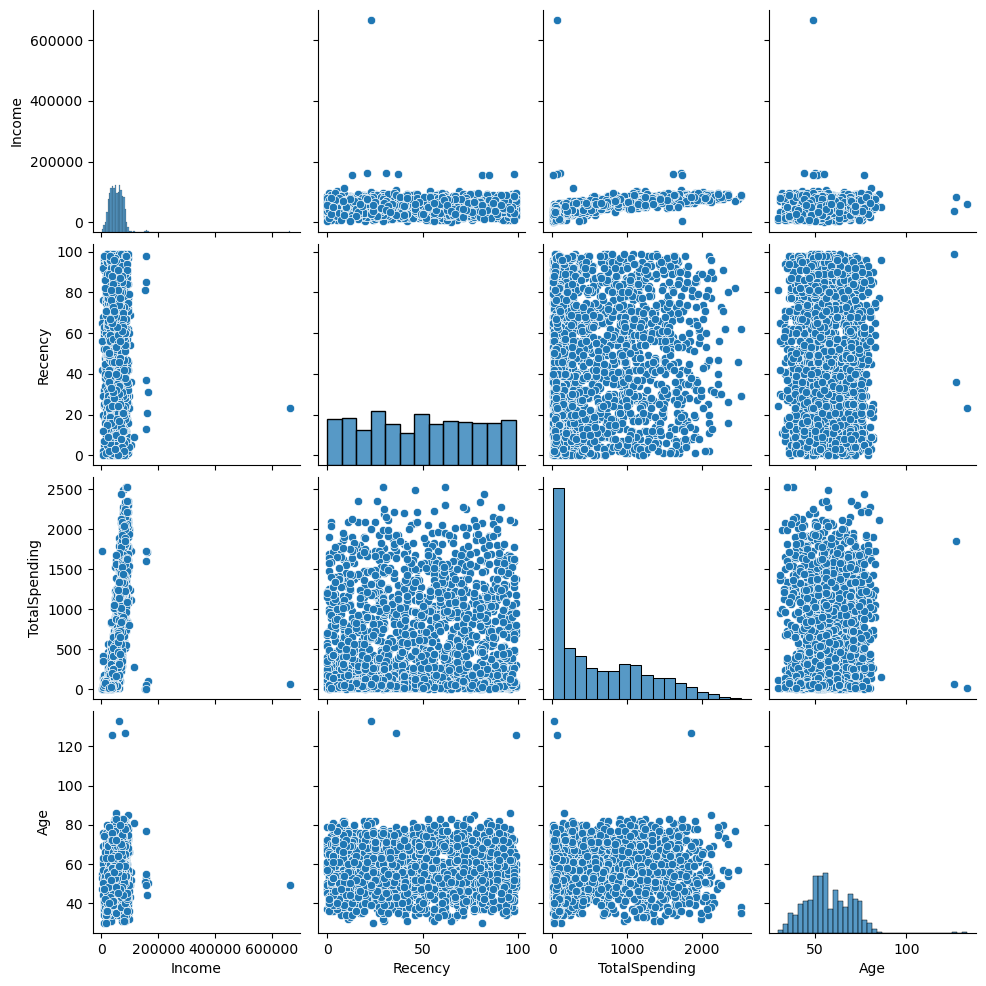

In [12]:
cols = ["Income", "Recency", "TotalSpending", "Age"]

plt.figure(figsize=(12,8))
sns.pairplot(data_cleaned[cols])
plt.show()

In [13]:
print("data size with outliers : ", len(data_cleaned))

data_cleaned = data_cleaned[data_cleaned["Age"] < 90]
data_cleaned = data_cleaned[data_cleaned["Income"] < 60_0000]

print("data size without outliers : ", len(data_cleaned))

data size with outliers :  2240
data size without outliers :  2236


## HeatMap

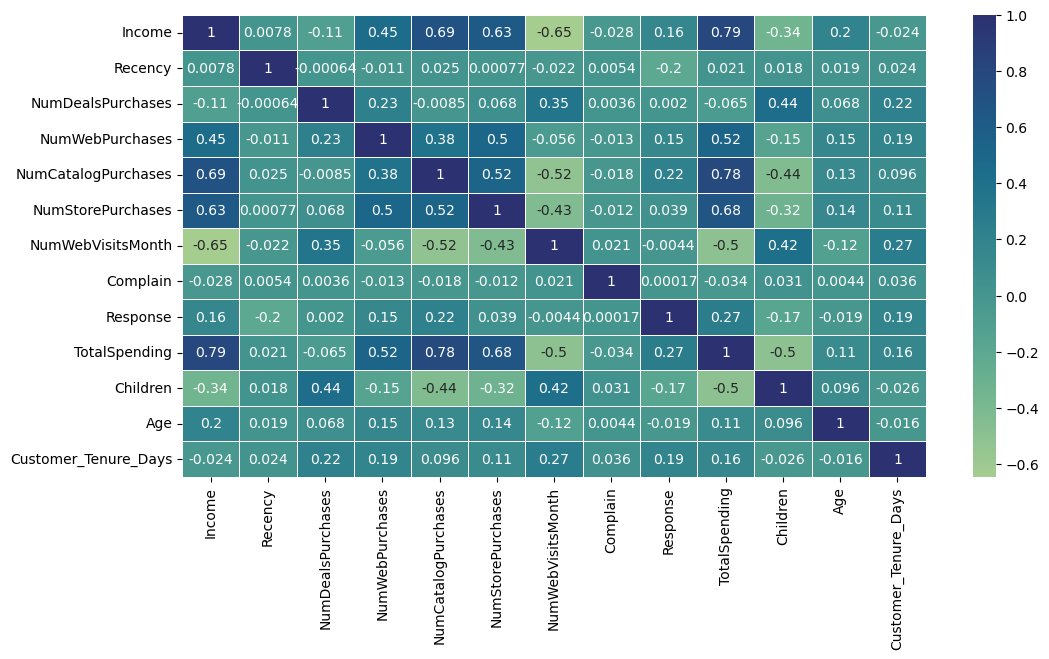

In [14]:
num_cols = data_cleaned.select_dtypes(include = "number")
corr_matrix =num_cols.corr()

plt.figure(figsize = (12, 6))
sns.heatmap(data = corr_matrix, cmap ="crest", annot = True, linewidth = .5)
plt.show()

## Encoding 

In [15]:
from sklearn.preprocessing import OneHotEncoder

cols = data_cleaned.select_dtypes(include = object).columns 

ohe = OneHotEncoder(sparse_output = False)
encoded = ohe.fit_transform(data_cleaned[cols])

encoded_df = pd.DataFrame(encoded, columns = ohe.get_feature_names_out(cols), index = data_cleaned.index)
data_cleaned = pd.concat([data_cleaned.drop(columns = data_cleaned[cols]), encoded_df], axis=1)

## Scaling

In [16]:
from sklearn.preprocessing import StandardScaler
X = data_cleaned

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Visualization

In [18]:
# 2D 

from sklearn.decomposition import PCA

pca = PCA(n_components = 2, random_state = 42)
X_pca = pca.fit_transform(X_scaled)

<Axes: >

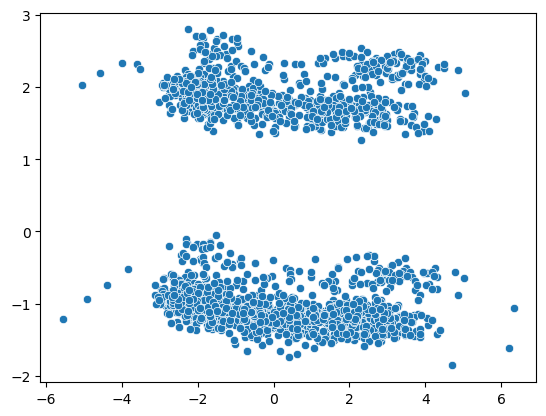

In [19]:
sns.scatterplot(x = X_pca[:, 0], y = X_pca[:, 1])

In [20]:
pca.explained_variance_ratio_.sum()

np.float64(0.3454861173547863)

In [21]:
# 3D 
pca = PCA(n_components = 3)
X_pca = pca.fit_transform(X_scaled)

Text(0.5, 0.92, '3D projrction')

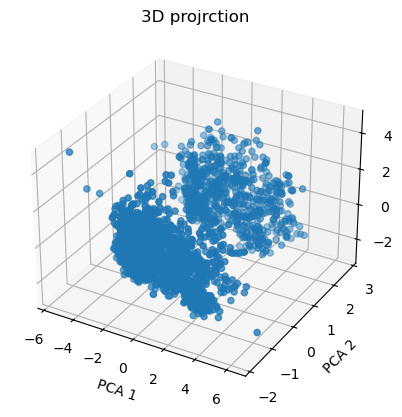

In [22]:
fig = plt.figure()

ax = fig.add_subplot(111, projection = "3d")
ax.scatter(xs = X_pca[:, 0], ys=X_pca[:, 1], zs = X_pca[:, 2])

ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
ax.set_title("3D projrction")

In [23]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

# Find Otptimum K Value
## Elbow method

In [24]:
import warnings
warnings.filterwarnings("ignore")

In [26]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []

for k in range(1, 11):
    Kmean = KMeans(n_clusters = k, random_state = 42)
    labels = Kmean.fit_predict(X_pca)
    wcss.append(Kmean.inertia_)

optimum_k = KneeLocator(range(1, 11), wcss, curve="convex", direction = "decreasing")  
print("Optimum k value is : " ,optimum_k.knee)

Optimum k value is :  4


<Axes: >

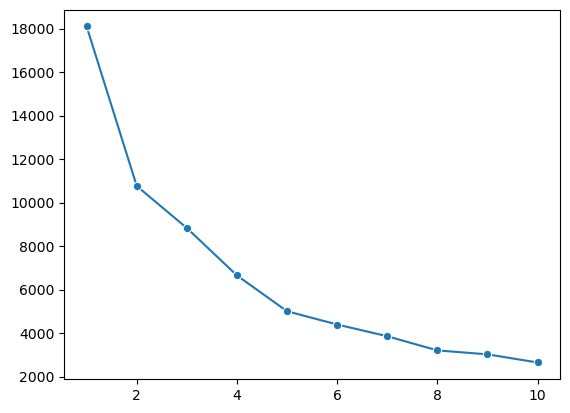

In [27]:
sns.lineplot(x=range(1, 11), y=wcss, marker = "o")

## Silhouette Score 

In [28]:
from sklearn.metrics import silhouette_score

ss = []

for k in range(2, 11):
    kmean = KMeans(n_clusters = k)
    labels = kmean.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels, random_state = 42)
    ss.append(score)

<Axes: >

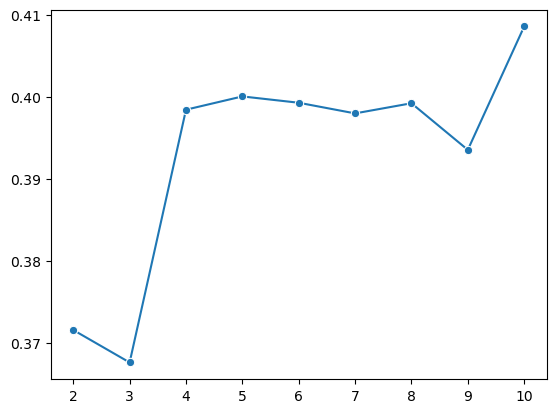

In [29]:
sns.lineplot(x = range(2, 11), y= ss, marker = "o")

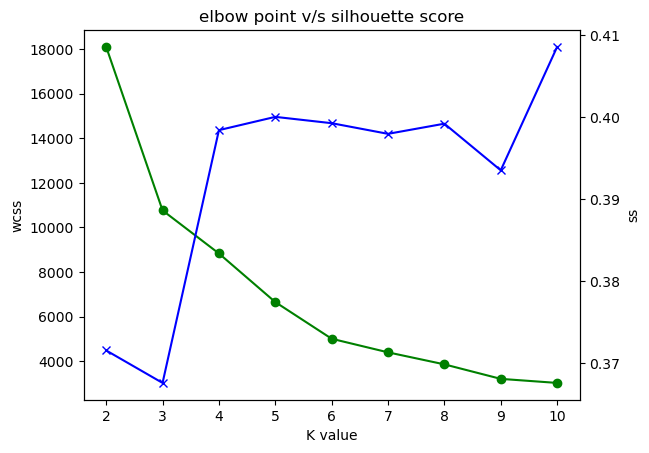

In [30]:
# combined plot
k_range = range(2, 11)

fig , ax1 = plt.subplots()

ax1.plot(k_range, wcss[:len(k_range)], marker = "o", color = "green")
ax1.set_xlabel("K value")
ax1.set_ylabel("wcss")

ax2 = ax1.twinx()
ax2.plot(k_range, ss[:len(k_range)], marker="x", color = "blue")
ax2.set_ylabel("ss")

plt.title("elbow point v/s silhouette score")
plt.show()


# Clustering 

In [31]:
kmean = KMeans(n_clusters = 4, random_state = 42)
labels = kmean.fit_predict(X_pca)

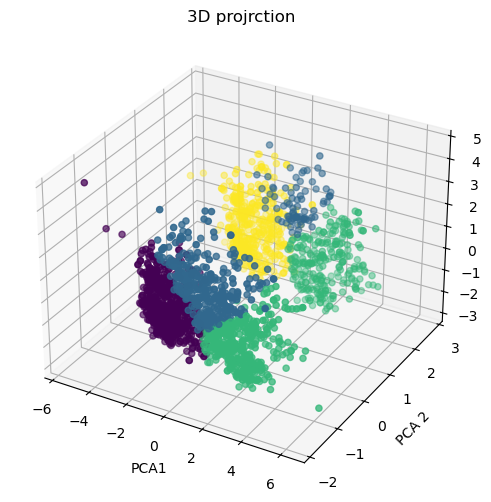

In [32]:
fig = plt.figure(figsize = (12, 6))

ax = fig.add_subplot(111, projection = "3d")

ax.scatter(X_pca[: , 0], X_pca[:, 1], X_pca[:, 2], c= labels )
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
ax.set_title("3D projrction")
plt.show()

# Agglomerative clustering 

In [33]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters = 4, linkage = "ward") 
labels = model.fit_predict(X_pca)

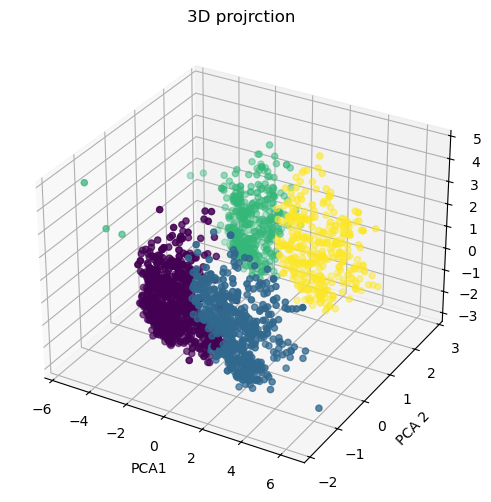

In [34]:
fig = plt.figure(figsize = (12, 6))

ax = fig.add_subplot(111, projection = "3d")

ax.scatter(X_pca[: , 0], X_pca[:, 1], X_pca[:, 2], c= labels )
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
ax.set_title("3D projrction")
plt.show()

## Characterization of Clusters 

In [35]:
data_cleaned["Clusters"] = labels

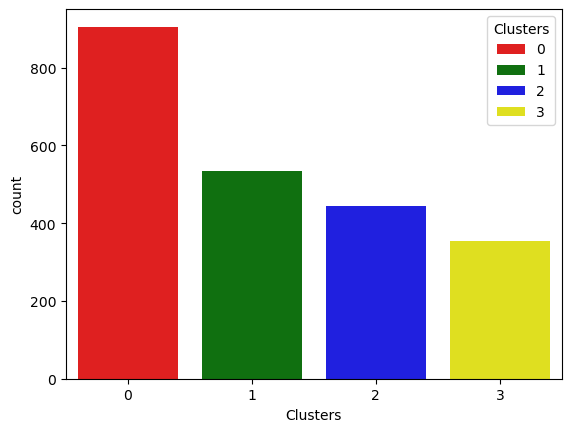

In [66]:
pal = ["red", "green", "blue", "yellow"]

sns.countplot(data = data_cleaned, x = data_cleaned["Clusters"], palette = pal, hue = data_cleaned["Clusters"])
plt.show()

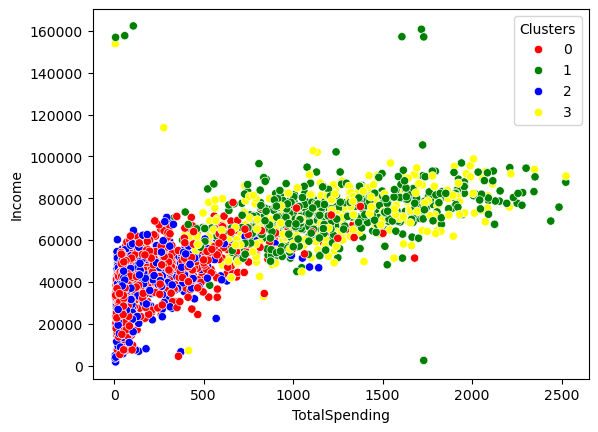

In [74]:
sns.scatterplot(x = data_cleaned["TotalSpending"], y = data_cleaned["Income"], hue=data_cleaned["Clusters"], palette = color)
plt.show()